# Resultados da Classificação do EC2 — Base Real de Tickets Pseudonimizados pelo AnonShield

**Estudo de Caso 2 — Minicurso "Inteligência Artificial aplicada à Resposta a Incidentes"**

## Sobre este notebook

Este notebook mostra os resultados da classificação de 182 incidentes **reais**
(pseudonimizados) de um CSIRT parceiro com três estratégias de prompt:
classificação livre, zero-shot e one-shot.

O conteúdo dos tickets não aparece aqui, somente identificadores numéricos e
categorias. O arquivo `resultados_reais.csv` que este notebook lê contém
apenas: `registro_id`, `incidente_id`, `esperado`, `rotulo_livre`, `zero_shot`,
`one_shot`.

> **Pré-requisito:** Coloque na mesma pasta deste notebook o arquivo resultados_reais.csv,
    que é gerado pelo notebook `02-classificacao_tickets_reais_interno.ipynb`, de uso interno.

## 1. Carregando os resultados

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = pd.read_csv("resultados_reais.csv")
print(f"{len(resultados)} tickets classificados.")
assert "conteudo" not in resultados.columns and "texto" not in resultados.columns

for col in ["zero_shot", "one_shot"]:
    resultados[f"{col}_ok"] = resultados[col] == resultados["esperado"]

resultados.head()


174 tickets classificados.


,registro_id,incidente_id,esperado,rotulo_livre,zero_shot,one_shot,zero_shot_ok,one_shot_ok
0,0,INC2022-125941,CAT12,Tentativa de Brute Force,CAT12,CAT12,True,True
1,1,INC2022-126521,CAT12,Tentativa de acesso indevido,CAT12,CAT12,True,True
2,2,INC2022-127135,CAT5,Configuração Insegura de Serviço,CAT5,CAT5,True,True
3,3,INC2022-138345,CAT5,Vulnerabilidade de infraestrutura,CAT12,CAT5,False,True
4,4,INC2022-140134,CAT5,Vulnerabilidade de Reflexão,CAT5,CAT5,True,True


## 2. Acurácia geral por estratégia

Classificação livre: 53 rótulos distintos para 174 tickets
Zero-shot: 68.4%
One-shot:  89.7%


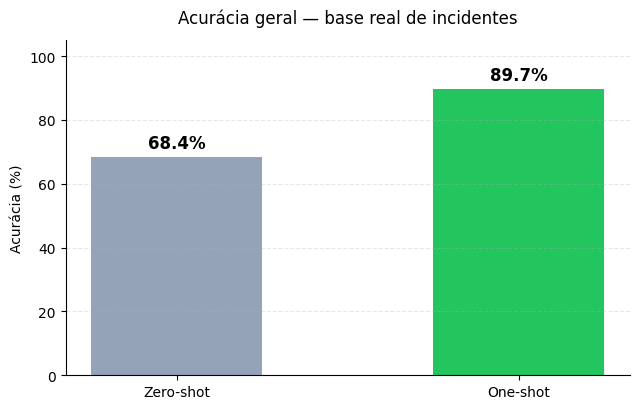

In [22]:
rotulos_livres_distintos = resultados["rotulo_livre"].str.lower().str.strip().nunique()
acc_zero = resultados["zero_shot_ok"].mean()
acc_one = resultados["one_shot_ok"].mean()

print(f"Classificação livre: {rotulos_livres_distintos} rótulos distintos para {len(resultados)} tickets")
print(f"Zero-shot: {acc_zero:.1%}")
print(f"One-shot:  {acc_one:.1%}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
tecnicas = ["Zero-shot", "One-shot"]
valores = [acc_zero * 100, acc_one * 100]
cores = ["#94a3b8", "#22c55e"]

barras = ax.bar(tecnicas, valores, color=cores, width=0.5)
for barra, valor in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 1.5, f"{valor:.1f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 105)
ax.set_ylabel("Acurácia (%)")
ax.set_title("Acurácia geral — base real de incidentes", fontsize=12, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Acurácia por categoria

Numa base desbalanceada (uma única categoria pode responder por boa parte dos
tickets), a acurácia geral pode esconder desempenho ruim nas categorias
minoritárias — por isso vale sempre olhar por categoria também.


In [23]:
por_categoria = resultados.groupby("esperado").agg(
    n_tickets=("esperado", "count"),
    acc_zero_shot=("zero_shot_ok", "mean"),
    acc_one_shot=("one_shot_ok", "mean"),
).sort_index(key=lambda idx: idx.str.replace("CAT", "").astype(int))

por_categoria["acc_zero_shot"] = (por_categoria["acc_zero_shot"] * 100).round(1)
por_categoria["acc_one_shot"] = (por_categoria["acc_one_shot"] * 100).round(1)

por_categoria


,n_tickets,acc_zero_shot,acc_one_shot
esperado,,,
CAT1,1,100.0,100.0
CAT2,3,66.7,66.7
CAT3,16,93.8,93.8
CAT5,117,60.7,91.5
CAT7,3,33.3,33.3
CAT9,6,83.3,83.3
CAT12,28,85.7,89.3


## 4. Matriz de confusão

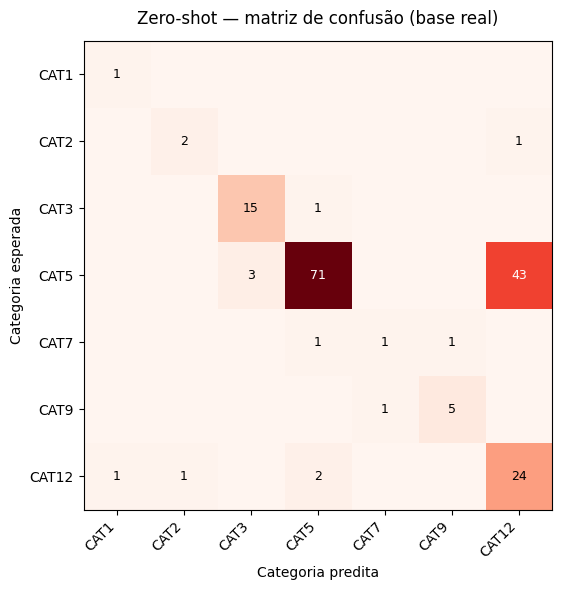

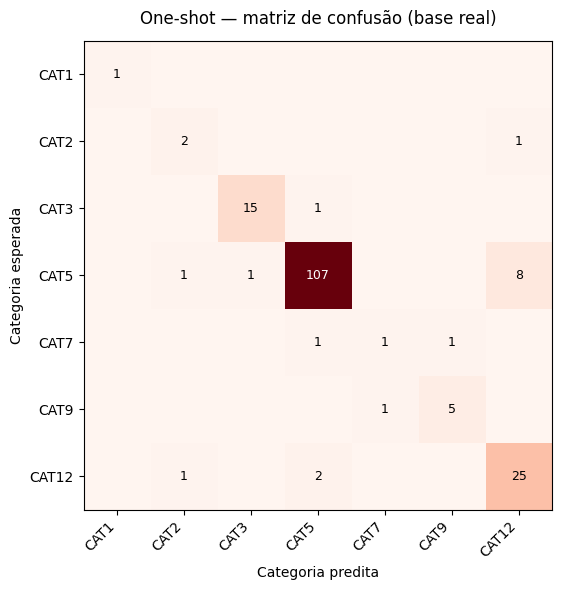

In [24]:
def plotar_matriz_confusao(df_r: pd.DataFrame, coluna_predita: str, titulo: str):
    categorias = sorted(
        set(df_r["esperado"]) | set(df_r[coluna_predita].dropna()),
        key=lambda c: int(c.replace("CAT", "")),
    )
    matriz = pd.crosstab(df_r["esperado"], df_r[coluna_predita]).reindex(
        index=categorias, columns=categorias, fill_value=0
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(matriz.values, cmap="Reds")

    ax.set_xticks(range(len(categorias)))
    ax.set_yticks(range(len(categorias)))
    ax.set_xticklabels(categorias, rotation=45, ha="right")
    ax.set_yticklabels(categorias)
    ax.set_xlabel("Categoria predita")
    ax.set_ylabel("Categoria esperada")
    ax.set_title(titulo, fontsize=12, pad=12)

    for i in range(len(categorias)):
        for j in range(len(categorias)):
            valor = matriz.values[i, j]
            if valor > 0:
                cor_texto = "white" if valor > matriz.values.max() / 2 else "black"
                ax.text(j, i, str(valor), ha="center", va="center", color=cor_texto, fontsize=9)

    plt.tight_layout()
    plt.show()


plotar_matriz_confusao(resultados, "zero_shot", "Zero-shot — matriz de confusão (base real)")
plotar_matriz_confusao(resultados, "one_shot", "One-shot — matriz de confusão (base real)")


## 5. Dispersão semântica (classificação livre)

Quantos rótulos diferentes o modelo usou para tickets da mesma categoria real
— sem taxonomia, é esperado que esse número seja alto.


In [25]:
for cat, grupo in resultados.groupby("esperado"):
    if len(grupo) > 1:
        distintos = grupo["rotulo_livre"].str.lower().str.strip().nunique()
        print(f"{cat} ({len(grupo)} tickets): {distintos} rótulo(s) distinto(s)")


CAT12 (28 tickets): 13 rótulo(s) distinto(s)
CAT2 (3 tickets): 3 rótulo(s) distinto(s)
CAT3 (16 tickets): 8 rótulo(s) distinto(s)
CAT5 (117 tickets): 27 rótulo(s) distinto(s)
CAT7 (3 tickets): 3 rótulo(s) distinto(s)
CAT9 (6 tickets): 3 rótulo(s) distinto(s)


## 6. Discussão

- **A acurácia por categoria conta uma história diferente da acurácia geral?**
  Em bases reais desbalanceadas, é comum que sim.
- **O one-shot ajudou mais nas categorias com poucos tickets, ou nas mais
  frequentes?**
- **Onde a matriz de confusão concentra os erros?** Compare com os padrões já
  discutidos no capítulo (confusão entre categorias conceitualmente próximas).

Estes resultados vêm de uma base real de incidentes de CSIRT (pseudonimizada),
mas nenhum conteúdo de ticket foi exibido neste notebook — apenas métricas
agregadas.
